In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import re
from copy import deepcopy
import json
import networkx as nx
from datetime import datetime, timedelta
#import us

### The below was snipped from:
https://github.com/NSSAC/FIELD_software/blob/main/phylogenetics/scripts/crossspecies_analysis.ipynb
on Feb 18 2026 

In [ ]:
#tree_filename = "../intermediate_data/nextstrain_metadata.tsv_2026_01_08.zst"
tree_filename = "/sfs/gpfs/tardis/project/bii_nssac/biocomplexity/vdh_genomics/synthetic_biosurveillance/PhyloGAS/outputs/run_03_vadelta_2026_03_22_128to428_SURS.tar.gz"

nextstrain = pd.read_csv("../intermediate_data/nextstrain_metadata.tsv_2026_01_08.zst", sep='\t')

In [38]:
# Purpose: Define a recursive function to traverse an augur JSON tree, extract state transitions, host information, and identify potential spillover events.
#recurse throught the json file to get edges between states
#create dataframe with columns state1, state2, divergence
hostCount = 0
child_count=0
hostMismatch =[]
nextstrainMismatch = []
nextstrainLookup = set(nextstrain['strain'])
spillover_data = {}
squandered_count=0
#hostLookup =bv_brc.set_index('Strain')['Host Name'].to_dict()
#hostLookup =nextstrain.set_index('strain')['host_category'].to_dict()

from datetime import datetime, timedelta

def decimal_date_to_datetime(dec_date):
    """Converts a decimal date to a datetime object."""
    if dec_date is None:
        return None
    year = int(dec_date)
    rem = dec_date - year
    base = datetime(year, 1, 1)
    # Check for leap year to use correct number of days
    days_in_year = 366 if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0) else 365
    result = base + timedelta(seconds=(rem * days_in_year * 24 * 3600))
    return result

hostLookup =combined_df.set_index('strain')['host_category'].to_dict()
spillover_table = pd.DataFrame(columns=[
    'spillover_type', 'decimal_date', 'state', 'day_interval', 
    'ancestor_day_interval', 'leaf_count', 'spillover_id', 'contributing_nodes'
])
leaf_table= pd.DataFrame(columns=['location', 'host', 'date', 'name'])
def year_month(date):
    year = int(date)
    month = int((date - int(date))*12)
    if month == 0:
        month = 1
    return f"{year}-{month:02d}"

from itertools import combinations

def augur_recurse(node, div_df, parentState=None, parentDiv=None, parentHost=None, init_count=None):
    global child_count, hostCount, hostMismatch, nextstrainLookup, spillover_table, leaf_table, hostLookup, spillover_data, squandered_count

    if init_count != None:
        child_count=init_count
    state = node.get("node_attrs", {}).get("division", {}).get("value", None)
    if state!=None and len(state) == 2:
        state_obj=us.states.lookup(state)
        if state_obj is not None:
            if state_obj.name == "Puerto Rico":
                print(f" hmm{state}")
            state=state_obj.name
    divergence = node.get("node_attrs", {}).get("div", {})
    host = node.get("node_attrs", {}).get("host", {}).get("value", "no host")
    date= node.get("node_attrs", {}).get("num_date", {}).get("value", None)
    name= node.get("name", None)
    node_attrs = node.get("node_attrs", {})
    #state = node_attrs.get("division", {}).get("value", None)
    host = node_attrs.get("host", {}).get("value", "no host")
    date = node_attrs.get("num_date", {}).get("value", None)
    
    # list of evidence dictionaries passed up the tree
    evidence_list = []

    if not name.startswith("NODE"):
        child_count += 1
        if name in hostLookup:
            host= hostLookup[name]
            hostCount+=1
        else:
            hostMismatch.append(name)
        
        if host == "Avian":
            if len(name.split("/")) > 2:
                host=categorize_host(name.split("/")[1])
                print(f"Avian {name}")

        if host != "no host":
            evidence_list.append({'name': name, 'host': host, 'state': state, 'date': date})

        # Populate leaf_table
        leaf_table = pd.concat([leaf_table, pd.DataFrame([{
            'location': state, 'host': host, 'date': date, 'name': name
        }])], ignore_index=True)

    #Recursive Step: Aggregate evidence from children
    for child in node.get("children", []):
        div_df, child_evidence_list = augur_recurse(child, div_df, state, date, host)
        evidence_list.extend(child_evidence_list)

    if len(evidence_list) > 1: # Only process if there are at least two leaves to form a pair
        
        # 1. Build the temporary index: {state: {host: [list_of_leaf_dicts]}}
        state_host_index = {}
        for leaf_dict in evidence_list:
            s = leaf_dict['state']
            h = leaf_dict['host']
            state_host_index.setdefault(s, {}).setdefault(h, []).append(leaf_dict)

        to_remove = set() # Use a set of unique leaf names to track exhausted evidence

        # 2. Iterate through the index to find and process spillovers
        for s, host_map in state_host_index.items():
            if s is None: continue # Skip leaves with no state information
            if len(host_map) > 1: # If more than one host type exists for this state
                
                for host1, host2 in combinations(host_map.keys(), 2):
                    
                    spillover_type = ",".join(sorted([host1, host2]))
                    contributing_leaves = host_map[host1] + host_map[host2]
                    contributing_nodes = [l['name'] for l in contributing_leaves]
                    
                    leaf_count = len(contributing_nodes)
                    leaf_dates = [l['date'] for l in contributing_leaves]
                    sample_datetimes = [decimal_date_to_datetime(d) for d in leaf_dates if d is not None]
                    
                    day_interval = (max(sample_datetimes) - min(sample_datetimes)).days if sample_datetimes and len(sample_datetimes) > 1 else 0
                    
                    ancestor_datetime = decimal_date_to_datetime(date)
                    ancestor_day_interval = max([(abs(ancestor_datetime - dt).days) for dt in sample_datetimes]) if sample_datetimes and ancestor_datetime else None

                    spillover_id = ",".join(sorted(contributing_nodes))
                    spillover_table = pd.concat([spillover_table, pd.DataFrame([{
                        'spillover_type': spillover_type, 'decimal_date': date, 'state': s,
                        'day_interval': day_interval, 'ancestor_day_interval': ancestor_day_interval,
                        'leaf_count': leaf_count, 'spillover_id': spillover_id, 'contributing_nodes': spillover_id
                    }])], ignore_index=True)

                    for leaf_name in contributing_nodes:
                        to_remove.add(leaf_name)

        # 3. State-Specific Exhaustion
        if to_remove:
            unexhausted_evidence = [l for l in evidence_list if l['name'] not in to_remove]
            return div_df, unexhausted_evidence

    # If no spillovers were found, return all evidence
    return div_df, evidence_list

NameError: name 'nextstrain' is not defined

In [ ]:
###  Not sure this will work:
#tree_file = "/project/bii_nssac/biocomplexity/vdh_genomics/synthetic_biosurveillance/SARS-Cov2-Biosurveillance-Simulation/nextstrain/2026_02_16_delta_rate_17k_ref.tar.gz"
tree_filen = "/sfs/gpfs/tardis/project/bii_nssac/biocomplexity/vdh_genomics/synthetic_biosurveillance/PhyloGAS/outputs/run_03_vadelta_2026_03_22_128to428_SURS.tar.gz"


with open("../intermediate_data/avian-flu_h5n1-cattle-outbreak_genome_2026_01_07.json") as f:

    augur_output = json.load(f)
    child_count = 0
    div_df, child_data = augur_recurse(list(augur_output.items())[2][1], div_df, init_count=0)
    print(f"child count is {child_count}")


In [12]:
def decimal_date_to_datetime(dec_date):
    """Converts a decimal date to a datetime object."""
    if dec_date is None:
        return None
    year = int(dec_date)
    rem = dec_date - year
    base = datetime(year, 1, 1)
    # Check for leap year to use correct number of days
    days_in_year = 366 if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0) else 365
    result = base + timedelta(seconds=(rem * days_in_year * 24 * 3600))
    return result

In [4]:
working_dir = '/project/bii_nssac/people/bl4zc/pgcoe_genepi_analytics/'
nextstrain_tree_file = working_dir + 'data/nextstrain_tree_sample/run_03_vadelta_2026_03_22_128to428_SURS/ncov_with_hcov19_prefix.json'
#nextstrain_tree_file = working_dir + 'data/results/2026_02_16_delta_rate_17k_ref/ncov_with_accessions.json'

In [5]:
# Build a NetworkX DiGraph from a Nextstrain/augur v2 JSON

def load_nextstrain_json(path: str) -> dict:
    with open(path) as f:
        return json.load(f)


def flatten_node_attrs(node_attrs: dict) -> dict:
    """Flatten node_attrs by keeping the raw dict and exposing .value plus extra fields."""
    flat = {}
    for key, val in node_attrs.items():
        if isinstance(val, dict) and "value" in val:
            flat[key] = val.get("value")
            for extra_key, extra_val in val.items():
                if extra_key != "value":
                    flat[f"{key}__{extra_key}"] = extra_val
        else:
            flat[key] = val
    return flat


def add_node_recursive(G: nx.DiGraph, node: dict, parent: str | None = None) -> None:
    name = node.get("name")
    raw_node_attrs = node.get("node_attrs", {})
    flat_attrs = flatten_node_attrs(raw_node_attrs)
    # Preserve both flattened and raw node attributes
    G.add_node(name, raw_node_attrs=raw_node_attrs, **flat_attrs)

    if parent is not None:
        edge_attrs = node.get("branch_attrs", {})
        # Keep raw branch attrs while also exposing fields directly on the edge
        G.add_edge(parent, name, raw_branch_attrs=edge_attrs, **edge_attrs)

    for child in node.get("children", []):
        add_node_recursive(G, child, name)


def nextstrain_tree_to_digraph(data: dict) -> nx.DiGraph:
    tree = data["tree"]
    G = nx.DiGraph()
    add_node_recursive(G, tree, parent=None)
    return G


json_path = nextstrain_tree_file
nextstrain_json = load_nextstrain_json(json_path)
G = nextstrain_tree_to_digraph(nextstrain_json)

print(f"Graph built. Nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")
root_name = nextstrain_json["tree"]["name"]
print(f"Root node {root_name} attribute keys: {list(G.nodes[root_name].keys())[:10]}")
print(f"First few children of root: {list(G.successors(root_name))[:5]}")

Graph built. Nodes: 28980, edges: 28979
Root node NODE_0000000 attribute keys: ['raw_node_attrs', 'div', 'num_date', 'num_date__confidence', 'region', 'region__confidence', 'region__entropy', 'clade_membership', 'emerging_lineage', 'country']
First few children of root: ['Wuhan/Hu-1/2019', 'NODE_0000001']


In [6]:
G.nodes()

NodeView(('NODE_0000000', 'Wuhan/Hu-1/2019', 'NODE_0000001', '21L', 'NODE_0000002', 'NODE_0000003', 'NODE_0000004', 'NODE_0000074', 'USA/VA-EHip-367722994.322/2021', 'NODE_0000075', 'NODE_0000007', 'USA/VA-EHip-365203582.368/2021', 'NODE_0000076', 'USA/VA-EHip-367166909.294/2021', 'USA/VA-EHip-367167510.390/2021', 'NODE_0000078', 'NODE_0000079', 'USA/VA-EHip-364755820.244/2021', 'USA/VA-EHip-363221312.252/2021', 'NODE_0000080', 'USA/VA-EHip-365373528.239/2021', 'NODE_0000012', 'USA/VA-EHip-365358995.329/2021', 'NODE_0000082', 'USA/VA-EHip-362288420.331/2021', 'USA/VA-EHip-362321316.366/2021', 'NODE_0000014', 'NODE_0000015', 'NODE_0000062', 'USA/VA-EHip-363200850.421/2022', 'NODE_0000063', 'USA/VA-EHip-367003496.288/2021', 'USA/VA-EHip-368770464.287/2021', 'USA/VA-EHip-367697497.286/2021', 'USA/VA-EHip-367670765.278/2021', 'NODE_0000018', 'NODE_0000020', 'USA/VA-EHip-367706200.316/2021', 'USA/VA-EHip-367822328.318/2021', 'NODE_0000021', 'USA/VA-EHip-367929505.327/2021', 'NODE_0000022', 

In [9]:
G.nodes['NODE_0000075']

{'raw_node_attrs': {'div': 28,
  'num_date': {'value': 2021.423, 'confidence': [2021.407, 2021.488]},
  'region': {'value': 'North America',
   'confidence': {'North America': 1.0},
   'entropy': 3.96e-11},
  'clade_membership': {'value': '21I (Delta)'},
  'emerging_lineage': {'value': '21I'},
  'country': {'value': 'USA', 'confidence': {'USA': 1.0}, 'entropy': 3.96e-11},
  'S1_mutations': {'value': 9.0},
  'current_frequency': {'value': 0.0},
  'mutational_fitness': {'value': 0.841}},
 'div': 28,
 'num_date': 2021.423,
 'num_date__confidence': [2021.407, 2021.488],
 'region': 'North America',
 'region__confidence': {'North America': 1.0},
 'region__entropy': 3.96e-11,
 'clade_membership': '21I (Delta)',
 'emerging_lineage': '21I',
 'country': 'USA',
 'country__confidence': {'USA': 1.0},
 'country__entropy': 3.96e-11,
 'S1_mutations': 9.0,
 'current_frequency': 0.0,
 'mutational_fitness': 0.841}

In [10]:
# Extract metadata from NODE* internal nodes and their children into a DataFrame

def collect_child_metadata(
    G: nx.DiGraph,
    metadata_keys: list[str] | None = None,
    node_prefix: str = "NODE",
) -> pd.DataFrame:
    """Return one row per internal node whose name starts with node_prefix.

    Each row captures metadata for the NODE itself (no prefix) and the first two
    children (child1_, child2_), records child_count, and lists extra children.
    """
    if metadata_keys is None:
        metadata_keys = ["num_date", "num_date__confidence", "county", "clade_membership"]

    records = []
    for node in G.nodes:
        if not str(node).startswith(node_prefix):
            continue
        children = list(G.successors(node))
        row = {"node": node, "child_count": len(children)}

        # Metadata on the NODE itself (no prefix)
        node_attrs = G.nodes[node]
        for key in metadata_keys:
            row[key] = node_attrs.get(key)

        # Metadata for first two children
        for idx, child in enumerate(children[:2], start=1):
            row[f"child{idx}_name"] = child
            attrs = G.nodes[child]
            for key in metadata_keys:
                row[f"child{idx}_{key}"] = attrs.get(key)

        # Capture any additional children beyond the first two
        if len(children) > 2:
            row["extra_children"] = children[2:]

        records.append(row)

    return pd.DataFrame.from_records(records)


# Example usage
metadata_keys = ["num_date", "num_date__confidence", "county", "clade_membership"]
node_children_df = collect_child_metadata(G, metadata_keys=metadata_keys)
node_children_df.head()

,node,child_count,num_date,num_date__confidence,county,clade_membership,child1_name,child1_num_date,child1_num_date__confidence,child1_county,child1_clade_membership,child2_name,child2_num_date,child2_num_date__confidence,child2_county,child2_clade_membership,extra_children
0,NODE_0000000,2,2019.985,"[2019.872, 2019.985]",None,19A,Wuhan/Hu-1/2019,2019.985,"[2019.985, 2019.985]",None,19A,NODE_0000001,2020.200,"[2018.68, 2020.399]",None,20A,NaN
1,NODE_0000001,2,2020.200,"[2018.68, 2020.399]",None,20A,21L,2021.834,"[2021.834, 2021.834]",None,21L (BA.2),NODE_0000002,2020.751,"[2019.825, 2021.186]",None,21A (Delta),NaN
2,NODE_0000002,2,2020.751,"[2019.825, 2021.186]",None,21A (Delta),NODE_0000003,2020.898,"[2020.221, 2021.326]",None,21A (Delta),NODE_0000594,2021.085,"[2020.684, 2021.289]",None,21J (Delta),NaN
3,NODE_0000003,2,2020.898,"[2020.221, 2021.326]",None,21A (Delta),NODE_0000004,2021.398,"[2021.384, 2021.439]",None,21I (Delta),NODE_0000153,2021.107,"[2020.655, 2021.342]",None,21A (Delta),NaN
4,NODE_0000004,2,2021.398,"[2021.384, 2021.439]",None,21I (Delta),NODE_0000074,2021.407,"[2021.397, 2021.474]",None,21I (Delta),NODE_0000014,2021.405,"[2021.39, 2021.442]",None,21I (Delta),NaN


In [13]:
# Convert decimal num_date columns to datetime
num_date_cols = [c for c in node_children_df.columns if c.endswith("num_date") and "__" not in c]
for col in num_date_cols:
    node_children_df[col] = node_children_df[col].apply(decimal_date_to_datetime)

# Extract sim_pid and tick from child*_name when containing EHip-
name_cols = [c for c in node_children_df.columns if c.endswith("_name") and c.startswith("child")]
pattern = r"EHip-(?P<sim_pid>\d{9})\.(?P<tick>\d{3})/"
for col in name_cols:
    extracted = node_children_df[col].astype(str).str.extract(pattern)
    prefix = col.replace("_name", "")
    node_children_df[f"{prefix}_sim_pid"] = extracted["sim_pid"]
    node_children_df[f"{prefix}_tick"] = extracted["tick"]

# Day differences between parent num_date and child num_date columns
for idx in (1, 2):
    child_col = f"child{idx}_num_date"
    if child_col in node_children_df.columns:
        delta = node_children_df[child_col] - node_children_df["num_date"]
        node_children_df[f"child{idx}_num_date_delta_days"] = delta.dt.days

# Child type classification: internal vs sim
for idx in (1, 2):
    name_col = f"child{idx}_name"
    type_col = f"child{idx}_type"
    if name_col in node_children_df.columns:
        names = node_children_df[name_col].astype(str)
        node_children_df[type_col] = np.where(
            names.str.startswith("NODE"), "internal",
            np.where(names.str.contains("EHip"), "sim", "other")
        )

# Consolidated child type: if both children same, else mixed
if {"child1_type", "child2_type"}.issubset(node_children_df.columns):
    node_children_df["child_type_combined"] = np.where(
        node_children_df["child1_type"] == node_children_df["child2_type"],
        node_children_df["child1_type"],
        "mixed",
    )

node_children_df.head()

,node,child_count,num_date,num_date__confidence,county,clade_membership,child1_name,child1_num_date,child1_num_date__confidence,child1_county,...,extra_children,child1_sim_pid,child1_tick,child2_sim_pid,child2_tick,child1_num_date_delta_days,child2_num_date_delta_days,child1_type,child2_type,child_type_combined
0,NODE_0000000,2,2019-12-26 12:35:59.999997,"[2019.872, 2019.985]",None,19A,Wuhan/Hu-1/2019,2019-12-26 12:35:59.999997,"[2019.985, 2019.985]",None,...,NaN,NaN,NaN,NaN,NaN,0,78,other,internal,mixed
1,NODE_0000001,2,2020-03-14 04:48:00.000001,"[2018.68, 2020.399]",None,20A,21L,2021-11-01 09:50:24.000002,"[2021.834, 2021.834]",None,...,NaN,NaN,NaN,NaN,NaN,597,201,other,internal,mixed
2,NODE_0000002,2,2020-10-01 20:47:02.399999,"[2019.825, 2021.186]",None,21A (Delta),NODE_0000003,2020-11-24 16:01:55.199997,"[2020.221, 2021.326]",None,...,NaN,NaN,NaN,NaN,NaN,53,122,internal,internal,internal
3,NODE_0000003,2,2020-11-24 16:01:55.199997,"[2020.221, 2021.326]",None,21A (Delta),NODE_0000004,2021-05-26 06:28:47.999997,"[2021.384, 2021.439]",None,...,NaN,NaN,NaN,NaN,NaN,182,76,internal,internal,internal
4,NODE_0000004,2,2021-05-26 06:28:47.999997,"[2021.384, 2021.439]",None,21I (Delta),NODE_0000074,2021-05-29 13:19:11.999998,"[2021.397, 2021.474]",None,...,NaN,NaN,NaN,NaN,NaN,3,2,internal,internal,internal


In [14]:
gen_df = node_children_df
gen_G = G

In [17]:
# Use the simulation child names that actually exist in the graph

graph_for_paths_undirected = gen_G.to_undirected()
sim_names = pd.concat([
    gen_df.loc[gen_df.child1_type == 'sim', 'child1_name'],
    gen_df.loc[gen_df.child2_type == 'sim', 'child2_name']
], ignore_index=True).dropna().unique()
sim_names = [n for n in sim_names if n in graph_for_paths_undirected.nodes]
if len(sim_names) < 2:
    raise ValueError("Need at least two simulation node names present in the graph to sample paths.")

iterations = 1000
rng = np.random.default_rng()
path_summaries = []

for i in range(1, iterations + 1):
    id1, id2 = rng.choice(sim_names, size=2, replace=False)
    try:
        path = nx.shortest_path(graph_for_paths_undirected, source=id1, target=id2)
    except nx.NetworkXNoPath:
        # Skip if these two nodes are not connected even in undirected view
        print(f"No path between {id1} and {id2}, skipping iteration {i}.")
        continue

    path_details = []
    for node in path:
        num_date = graph_for_paths_undirected.nodes[node].get('num_date')
        dt = decimal_date_to_datetime(num_date)
        path_details.append({
            'node': node,
            'num_date': num_date,
            'date_dt': dt
        })

    common_dt = min(
        [p['date_dt'] for p in path_details if p['date_dt'] is not None],
        default=None
    )

    id1_dt = decimal_date_to_datetime(graph_for_paths_undirected.nodes[id1].get('num_date'))
    id2_dt = decimal_date_to_datetime(graph_for_paths_undirected.nodes[id2].get('num_date'))
    id1_diff = (id1_dt - common_dt).days if id1_dt is not None and common_dt is not None else None
    id2_diff = (id2_dt - common_dt).days if id2_dt is not None and common_dt is not None else None

    # Extract sim pid and tick from ids if present
    m1 = re.search(pattern, str(id1)) if 'pattern' in globals() else re.search(r"EHip-(?P<sim_pid>\d{9})\.(?P<tick>\d{3})/", str(id1))
    m2 = re.search(pattern, str(id2)) if 'pattern' in globals() else re.search(r"EHip-(?P<sim_pid>\d{9})\.(?P<tick>\d{3})/", str(id2))
    id1_sim_pid = m1.group('sim_pid') if m1 else None
    id1_sim_tick = m1.group('tick') if m1 else None
    id2_sim_pid = m2.group('sim_pid') if m2 else None
    id2_sim_tick = m2.group('tick') if m2 else None

    path_summaries.append({
        'iteration': i,
        'id1': id1,
        'id2': id2,
        'id1_sim_pid': id1_sim_pid,
        'id1_sim_tick': id1_sim_tick,
        'id2_sim_pid': id2_sim_pid,
        'id2_sim_tick': id2_sim_tick,
        'path_length': len(path) - 1,
        'id1_date': id1_dt.date().isoformat() if id1_dt is not None else None,
        'id2_date': id2_dt.date().isoformat() if id2_dt is not None else None,
        'common_ancestor_date': common_dt.date().isoformat() if common_dt is not None else None,
        'id1_days_from_ancestor': id1_diff,
        'id2_days_from_ancestor': id2_diff,
        'path_nodes': " -> ".join([p['node'] for p in path_details]),
        'path_num_dates': [p['num_date'] for p in path_details],
        'path_dates': [p['date_dt'].date().isoformat() if p['date_dt'] is not None else None for p in path_details]
    })

path_summary_df = pd.DataFrame(path_summaries)
path_summary_df.sample(3)

,iteration,id1,id2,id1_sim_pid,id1_sim_tick,id2_sim_pid,id2_sim_tick,path_length,id1_date,id2_date,common_ancestor_date,id1_days_from_ancestor,id2_days_from_ancestor,path_nodes,path_num_dates,path_dates
745,746,USA/VA-EHip-361695093.420/2022,USA/VA-EHip-366218995.361/2021,361695093,420,366218995,361,49,2022-01-30,2021-12-01,2021-05-20,255,195,USA/VA-EHip-361695093.420/2022 -> NODE_0014277...,"[2022.081, 2021.979, 2021.955, 2021.916, 2021....","[2022-01-30, 2021-12-24, 2021-12-15, 2021-12-0..."
512,513,USA/VA-EHip-364419274.347/2021,USA/VA-EHip-361240973.268/2021,364419274,347,361240973,268,60,2021-11-17,2021-08-30,2021-04-08,223,144,USA/VA-EHip-364419274.347/2021 -> NODE_0003796...,"[2021.878, 2021.878, 2021.575, 2021.549, 2021....","[2021-11-17, 2021-11-17, 2021-07-29, 2021-07-2..."
875,876,USA/VA-EHip-363698328.271/2021,USA/VA-EHip-364022706.422/2022,363698328,271,364022706,422,28,2021-09-02,2022-01-31,2021-04-08,147,298,USA/VA-EHip-363698328.271/2021 -> NODE_0001842...,"[2021.67, 2021.661, 2021.628, 2021.473, 2021.4...","[2021-09-02, 2021-08-30, 2021-08-18, 2021-06-2..."


<Axes: xlabel='path_length', ylabel='mean_days_from_ancestor'>

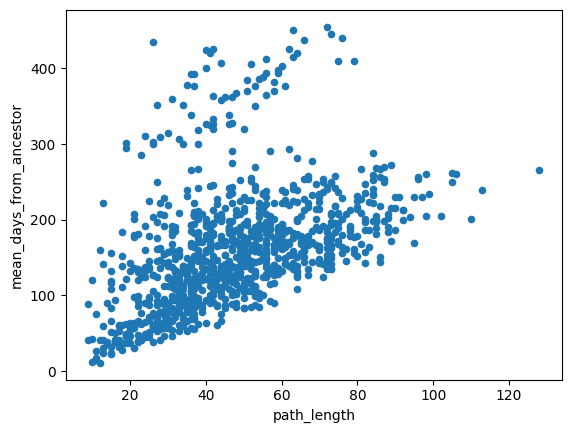

In [18]:
path_summary_df['mean_days_from_ancestor'] = path_summary_df[['id1_days_from_ancestor', 'id2_days_from_ancestor']].mean(axis=1)

path_summary_df.plot("path_length","mean_days_from_ancestor",kind="scatter")

In [19]:
path_summary_df[path_summary_df.mean_days_from_ancestor> 200]

,iteration,id1,id2,id1_sim_pid,id1_sim_tick,id2_sim_pid,id2_sim_tick,path_length,id1_date,id2_date,common_ancestor_date,id1_days_from_ancestor,id2_days_from_ancestor,path_nodes,path_num_dates,path_dates,mean_days_from_ancestor
2,3,USA/VA-EHip-361896369.226/2021,USA/VA-EHip-368411739.299/2021,361896369,226,368411739,299,46,2021-07-19,2021-09-30,2020-10-01,290,363,USA/VA-EHip-361896369.226/2021 -> NODE_0007470...,"[2021.547, 2021.543, 2021.53, 2021.522, 2021.5...","[2021-07-19, 2021-07-18, 2021-07-13, 2021-07-1...",326.5
3,4,USA/VA-EHip-362184352.382/2021,USA/VA-EHip-361379119.268/2021,362184352,382,361379119,268,43,2021-12-22,2021-08-30,2021-04-08,258,144,USA/VA-EHip-362184352.382/2021 -> NODE_0003057...,"[2021.974, 2021.974, 2021.935, 2021.924, 2021....","[2021-12-22, 2021-12-22, 2021-12-08, 2021-12-0...",201.0
4,5,USA/VA-EHip-362219075.415/2022,USA/VA-EHip-363977354.283/2021,362219075,415,363977354,283,61,2022-01-25,2021-09-14,2021-04-08,292,159,USA/VA-EHip-362219075.415/2022 -> NODE_0003867...,"[2022.067, 2021.877, 2021.758, 2021.571, 2021....","[2022-01-25, 2021-11-17, 2021-10-04, 2021-07-2...",225.5
7,8,USA/VA-EHip-364757414.411/2022,USA/VA-EHip-362809907.419/2022,364757414,411,362809907,419,57,2022-01-20,2022-01-28,2021-04-08,287,295,USA/VA-EHip-364757414.411/2022 -> NODE_0014011...,"[2022.053, 2021.839, 2021.781, 2021.759, 2021....","[2022-01-20, 2021-11-03, 2021-10-13, 2021-10-0...",291.0
12,13,USA/VA-EHip-366294248.380/2021,USA/VA-EHip-361603205.368/2021,366294248,380,361603205,368,77,2021-12-20,2021-12-08,2021-05-20,214,202,USA/VA-EHip-366294248.380/2021 -> NODE_0009340...,"[2021.968, 2021.96, 2021.944, 2021.927, 2021.9...","[2021-12-20, 2021-12-17, 2021-12-11, 2021-12-0...",208.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,962,USA/VA-EHip-366507025.364/2021,USA/VA-EHip-368063093.362/2021,366507025,364,368063093,362,60,2021-12-04,2021-12-02,2021-04-08,240,238,USA/VA-EHip-366507025.364/2021 -> NODE_0001562...,"[2021.925, 2021.896, 2021.804, 2021.683, 2021....","[2021-12-04, 2021-11-24, 2021-10-21, 2021-09-0...",239.0
974,975,USA/VA-EHip-364828813.351/2021,USA/VA-EHip-368682370.402/2022,364828813,351,368682370,402,81,2021-11-19,2022-01-11,2021-05-20,183,236,USA/VA-EHip-364828813.351/2021 -> NODE_0010835...,"[2021.884, 2021.831, 2021.796, 2021.692, 2021....","[2021-11-19, 2021-10-31, 2021-10-18, 2021-09-1...",209.5
975,976,USA/VA-EHip-367660945.292/2021,USA/VA-EHip-364961800.397/2022,367660945,292,364961800,397,56,2021-09-23,2022-01-06,2021-04-08,168,273,USA/VA-EHip-367660945.292/2021 -> NODE_0012683...,"[2021.727, 2021.664, 2021.644, 2021.425, 2021....","[2021-09-23, 2021-08-31, 2021-08-24, 2021-06-0...",220.5
983,984,USA/VA-EHip-366161007.423/2022,USA/VA-EHip-362710014.321/2021,366161007,423,362710014,321,37,2022-02-01,2021-10-22,2021-05-20,257,155,USA/VA-EHip-366161007.423/2022 -> NODE_0005576...,"[2022.086, 2021.586, 2021.556, 2021.53, 2021.5...","[2022-02-01, 2021-08-02, 2021-07-22, 2021-07-1...",206.0


In [102]:
G.nodes['USA/VA-EHip-366023277.174/2021']

{'raw_node_attrs': {'div': 42,
  'num_date': {'value': 2021.39,
   'confidence': [2021.39, 2021.39],
   'inferred': False},
  'emerging_lineage': {'value': '21I'},
  'smh_race': {'value': 'White'},
  'country': {'value': 'USA', 'confidence': {'USA': 1.0}, 'entropy': -1e-12},
  'mutational_fitness': {'value': 0.852},
  'clade_membership': {'value': '21I (Delta)'},
  'age_group': {'value': 'Older adult (50-64)'},
  'current_frequency': {'value': 0.0},
  'county': {'value': 'Smyth VA',
   'confidence': {'Smyth VA': 1.0},
   'entropy': -1e-12},
  'S1_mutations': {'value': 9.0},
  'sex': {'value': 'female'},
  'epiweek': {'value': '202121'},
  'region': {'value': 'North America',
   'confidence': {'North America': 1.0},
   'entropy': -1e-12}},
 'div': 42,
 'num_date': 2021.39,
 'num_date__confidence': [2021.39, 2021.39],
 'num_date__inferred': False,
 'emerging_lineage': '21I',
 'smh_race': 'White',
 'country': 'USA',
 'country__confidence': {'USA': 1.0},
 'country__entropy': -1e-12,
 'muta

In [21]:
### Write the file for analysis elsewhere
suffix = "300day"
path_summary_df.to_csv(f"{working_dir}/data/nextstrain_tree_sample_paths_{suffix}.csv", index=False)

In [22]:
### Dump tree graph for reading elsewhere
import pickle
with open(f"{working_dir}/data/nextstrain_tree_graph_{suffix}.gpickle", 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)
###  To read use:   with open('test.gpickle', 'rb') as f:
###                     G = pickle.load(f)

node_children_df.to_csv(f'{working_dir}/data/nextstrain_tree_dataframe_{suffix}.csv',index=False)

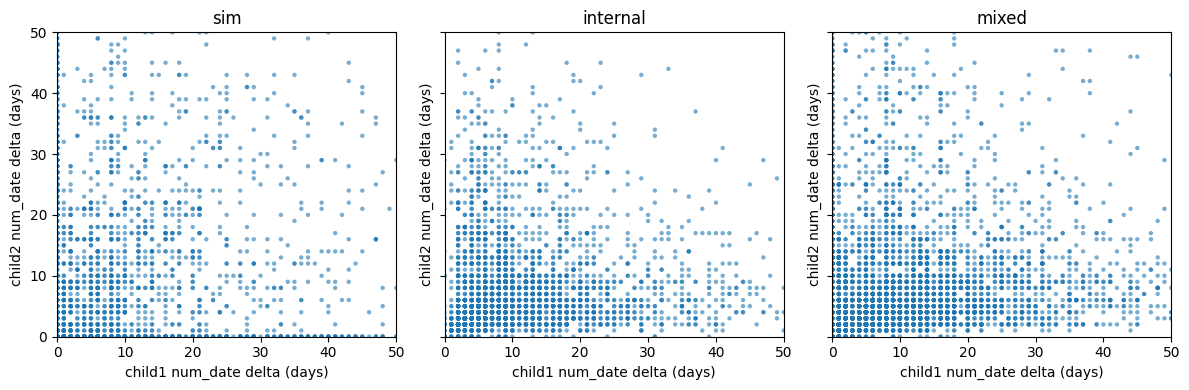

In [23]:
# Scatter plots of child num_date deltas by relationship type
rel_types = ["sim", "internal", "mixed"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, rel in zip(axes, rel_types):
    subset = node_children_df[node_children_df["child_type_combined"] == rel].dropna(subset=["child1_num_date_delta_days", "child2_num_date_delta_days"])
    ax.scatter(
        subset["child1_num_date_delta_days"],
        subset["child2_num_date_delta_days"],
        s=10,
        alpha=0.6,
        edgecolor="none",
    )
    ax.set_xlim([0,50])
    ax.set_ylim([0,50])
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_title(rel)
    ax.set_xlabel("child1 num_date delta (days)")
    ax.set_ylabel("child2 num_date delta (days)")

fig.tight_layout()


In [72]:
node_children_df[node_children_df.child_type_combined=='mixed'][['child1_type','child2_type']].value_counts()

child1_type  child2_type
sim          internal       6683
other        internal         10
sim          other             3
other        sim               2
Name: count, dtype: int64